# Optimization Benchmark Analysis
**Project:** Multivariate regression study on NLP solver performance  
**Authors:** Felix, Tangi, Nishan  
**Data:** `final.csv` — 7,493 solver runs × 98 columns

## 1. Imports & Setup

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA 

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

## 2. Load Data

In [32]:
# Row 7494 has a truncated quoted string — skip bad lines safely
df = pd.read_csv('./datasets/final.csv', on_bad_lines='skip', engine='python')
print(f'Shape: {df.shape}')  # expect (7493, 98)
df.head(3)

Shape: (34251, 98)


,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,name,dual_feas,status,timed_bytes,timed_time,...,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc,solved
0,5.0000,-3.6253,0.2684,0.1371,0.0000,AMPGO08,0.0000,first_order,9216.0000,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,True
1,5.0000,-3.6253,0.2684,0.0112,0.0000,AMPGO08,0.0000,first_order,9440.0000,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,True
2,5.0000,-3.6253,0.2684,0.0113,0.0000,AMPGO08,0.0000,first_order,9600.0000,0.0001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,True


## 3. Column Overview

| Column | Description |
|---|---|
| `stats_elapsed_time` | Total wall-clock time for the solver run (seconds). **Primary target.** |
| `neval_obj` | Number of objective function evaluations |
| `neval_grad` | Number of gradient evaluations |
| `timed_bytes` | Memory allocated during the timed section (bytes) |
| `timed_time` | Wall time of the timed section — nearly identical to `stats_elapsed_time` |
| `nvar` | Number of variables in the problem |
| `ncon` | Number of constraints |
| `iter` | Number of solver iterations |
| `status` | Solver exit status: `first_order`, `unbounded`, `time_limit` |
| `solved` | Boolean — did the solver succeed? |
| `nvmops` | Number of vector-matrix operations |
| `objective` | Final objective function value |
| `source_solver` | Which solver was used |
| `nlp_type` | Type of NLP problem |

> **Note:** `timed_time` and `stats_elapsed_time` have correlation ~1.0 — do **not** use `timed_time` as a predictor when the target is `stats_elapsed_time` (data leakage).

In [33]:
# Quick overview of key columns
key_cols = ['stats_elapsed_time', 'neval_obj', 'neval_grad', 'timed_bytes', 'nvar', 'ncon', 'iter']
df[key_cols].describe()

,stats_elapsed_time,neval_obj,neval_grad,timed_bytes,nvar,ncon,iter
count,34051.0000,33371.0000,33371.0000,33371.0000,34251.0000,21802.0000,33371.0000
mean,216.3370,1411.7312,1394.7747,405102324.3921,17001.2824,0.0000,1124.0029
std,646.7335,25669.1309,25649.0674,6946373513.9428,63566.5550,0.0000,19638.9583
min,0.0000,1.0000,1.0000,6752.0000,1.0000,0.0000,0.0000
25%,0.0008,25.0000,15.0000,56312.0000,8.0000,0.0000,11.0000
50%,0.0488,52.0000,40.0000,514184.0000,100.0000,0.0000,35.0000
75%,14.1726,205.0000,191.5000,5930272.0000,9999.0000,0.0000,172.0000
max,3600.0000,3093508.0000,3093260.0000,149211128144.0000,500000.0000,0.0000,2229748.0000


## 4. Existing Problems to Revisit (Tangi)

Rows skipped in the original script — check for parsing issues, extreme outliers, or errors.

In [34]:
# Rows with any error flags
print('=== error_solver value counts ===')
print(df['error_solver'].value_counts(dropna=False).head(10))
print()
print('=== error_problem value counts ===')
print(df['error_problem'].value_counts(dropna=False).head(10))
print()
print('=== error_type value counts ===')
print(df['error_type'].value_counts(dropna=False).head(10))

=== error_solver value counts ===
error_solver
NaN                       33571
Timeout after 3600.0 s      680
Name: count, dtype: int64

=== error_problem value counts ===
error_problem
NaN    34251
Name: count, dtype: int64

=== error_type value counts ===
error_type
NaN    34251
Name: count, dtype: int64


In [35]:
# Problems that were NOT solved
print('=== status distribution ===')
print(df['status'].value_counts())
print()
print('=== solved distribution ===')
print(df['solved'].value_counts())

# Flag: time_limit rows are likely the 'skipped' problems
time_limit_rows = df[df['status'] == 'time_limit']
print(f'\nRows hitting time limit: {len(time_limit_rows)}')
time_limit_rows[key_cols].describe()

=== status distribution ===
status
first_order    32871
time_limit       680
unbounded        500
Name: count, dtype: int64

=== solved distribution ===
solved
True     33571
False      680
Name: count, dtype: int64

Rows hitting time limit: 680


,stats_elapsed_time,neval_obj,neval_grad,timed_bytes,nvar,ncon,iter
count,680.0000,0.0000,0.0000,0.0000,680.0000,315.0000,0.0000
mean,3600.0000,NaN,NaN,NaN,250983.1868,0.0000,NaN
std,0.0000,NaN,NaN,NaN,219533.1972,0.0000,NaN
min,3600.0000,NaN,NaN,NaN,3.0000,0.0000,NaN
25%,3600.0000,NaN,NaN,NaN,99996.0000,0.0000,NaN
50%,3600.0000,NaN,NaN,NaN,100000.0000,0.0000,NaN
75%,3600.0000,NaN,NaN,NaN,500000.0000,0.0000,NaN
max,3600.0000,NaN,NaN,NaN,500000.0000,0.0000,NaN


## 5. Feature Engineering

### 5a. Categorical variable: time (`cat_time`)

Target: ~5 categories based on `stats_elapsed_time` (log scale makes sense given heavy skew).

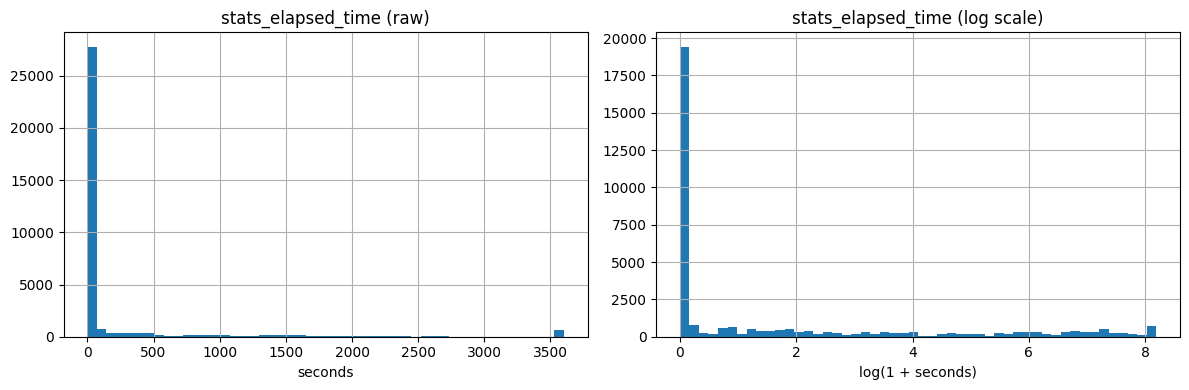

In [36]:
# Distribution of elapsed time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['stats_elapsed_time'].hist(bins=50, ax=axes[0])
axes[0].set_title('stats_elapsed_time (raw)')
axes[0].set_xlabel('seconds')

np.log1p(df['stats_elapsed_time']).hist(bins=50, ax=axes[1])
axes[1].set_title('stats_elapsed_time (log scale)')
axes[1].set_xlabel('log(1 + seconds)')
plt.tight_layout()
plt.show()

cat_time
instant      13355
fast          6950
moderate      4799
slow          2567
very_slow     6380
Name: count, dtype: int64



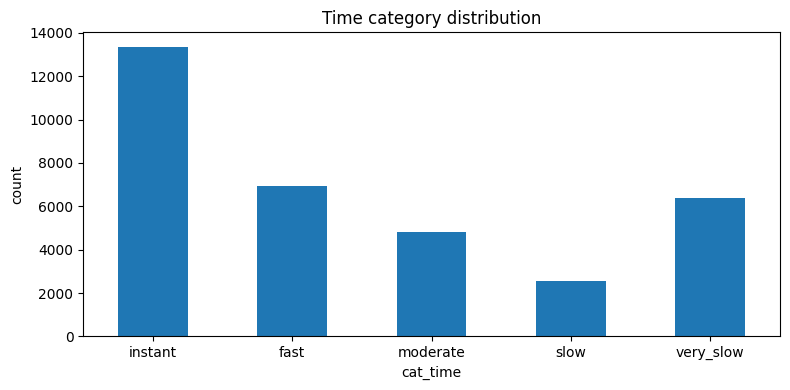

In [37]:
# Define 5 time categories (in seconds)
time_bins   = [-np.inf, 0.01, 0.5, 10, 60, np.inf]
time_labels = ['instant', 'fast', 'moderate', 'slow', 'very_slow']

df['cat_time'] = pd.cut(
    df['stats_elapsed_time'],
    bins=time_bins,
    labels=time_labels
)

print(df['cat_time'].value_counts().sort_index())
print()
# Visual check
df['cat_time'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4), title='Time category distribution')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5b. Categorical variable: number of variables (`cat_nvar`)

Target: ~5 categories based on `nvar` (ranges from 1 to 500,000 — use log bins).

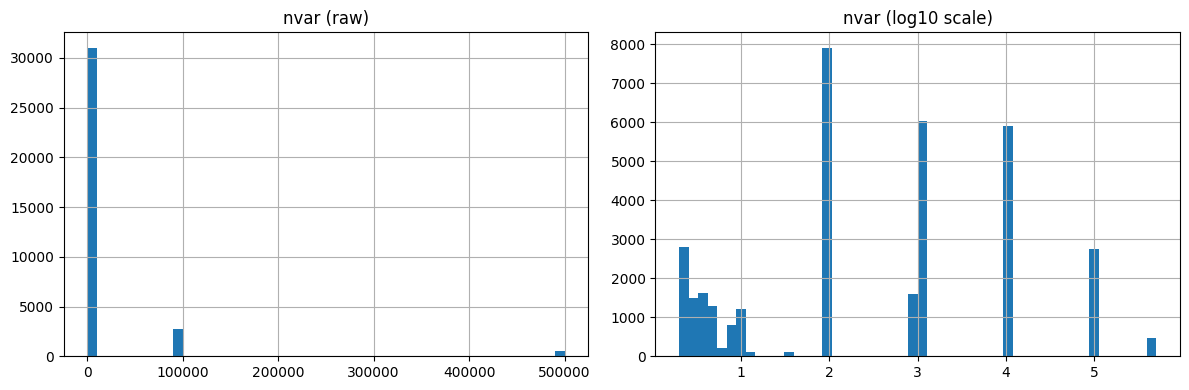

In [38]:
# Distribution of nvar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['nvar'].hist(bins=50, ax=axes[0])
axes[0].set_title('nvar (raw)')

np.log10(df['nvar'] + 1).hist(bins=50, ax=axes[1])
axes[1].set_title('nvar (log10 scale)')
plt.tight_layout()
plt.show()

cat_nvar
tiny          9416
small         8104
medium        7616
large         5889
very_large    3226
Name: count, dtype: int64



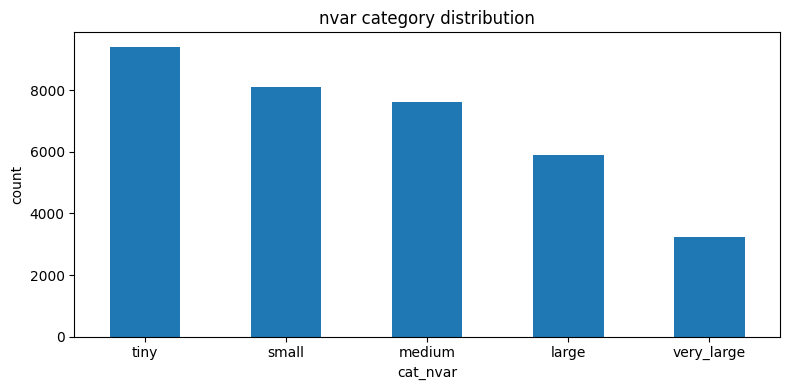

In [39]:
# Define 5 nvar categories
nvar_bins   = [0, 10, 100, 1_000, 10_000, np.inf]
nvar_labels = ['tiny', 'small', 'medium', 'large', 'very_large']

df['cat_nvar'] = pd.cut(
    df['nvar'],
    bins=nvar_bins,
    labels=nvar_labels
)

print(df['cat_nvar'].value_counts().sort_index())
print()
df['cat_nvar'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4), title='nvar category distribution')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5c. Add new features to feature_cols

In [40]:
# Log-transform skewed predictors to stabilise variance
df['log_nvar']      = np.log1p(df['nvar'])
df['log_timed_bytes'] = np.log1p(df['timed_bytes'])
df['log_neval_obj'] = np.log1p(df['neval_obj'])
df['log_neval_grad']= np.log1p(df['neval_grad'])

# Core feature columns for regression
feature_cols = [
    'log_nvar',          # problem size
    'log_timed_bytes',   # memory usage
    'log_neval_obj',     # obj function calls
    'log_neval_grad',    # gradient calls
    'ncon',              # number of constraints
    'iter',              # solver iterations
]

print('Feature columns:', feature_cols)
print()
df[feature_cols].describe()

Feature columns: ['log_nvar', 'log_timed_bytes', 'log_neval_obj', 'log_neval_grad', 'ncon', 'iter']



,log_nvar,log_timed_bytes,log_neval_obj,log_neval_grad,ncon,iter
count,34251.0000,33371.0000,33371.0000,33371.0000,21802.0000,33371.0000
mean,5.6738,13.5732,4.3588,4.1546,0.0000,1124.0029
std,3.4013,2.8919,1.8610,1.9709,0.0000,19638.9583
min,0.6931,8.8177,0.6931,0.6931,0.0000,0.0000
25%,2.1972,10.9387,3.2581,2.7726,0.0000,11.0000
50%,4.6151,13.1503,3.9703,3.7136,0.0000,35.0000
75%,9.2103,15.5956,5.3279,5.2601,0.0000,172.0000
max,13.1224,25.7286,14.9448,14.9447,0.0000,2229748.0000


## 6. Prepare Regression Dataset

In [41]:
# Log-transform the target too (skewed 0 → 3600)
df['log_elapsed'] = np.log1p(df['stats_elapsed_time'])

# Drop rows with any NaN in features or target
reg_cols = feature_cols + ['log_elapsed']
df_reg = df[reg_cols].dropna()
print(f'Regression dataset: {df_reg.shape[0]} rows (dropped {len(df) - len(df_reg)} with NaNs)')

X_raw = df_reg[feature_cols]
y     = df_reg['log_elapsed']

# Add constant for statsmodels
X = sm.add_constant(X_raw)

Regression dataset: 21487 rows (dropped 12764 with NaNs)


## 7. Regressor: Predict `stats_elapsed_time`

Can we predict elapsed time from `neval_obj`, `neval_grad`, `timed_bytes`?

In [42]:
# Simple OLS: log_elapsed ~ log_neval_obj + log_neval_grad + log_timed_bytes
X_simple = sm.add_constant(df_reg[['log_neval_obj', 'log_neval_grad', 'log_timed_bytes']])

elapsed_model = sm.OLS(y, X_simple).fit()
print(elapsed_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_elapsed   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                 1.252e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:48:38   Log-Likelihood:                -39439.
No. Observations:               21487   AIC:                         7.889e+04
Df Residuals:                   21483   BIC:                         7.892e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -11.2834      0.073   -1

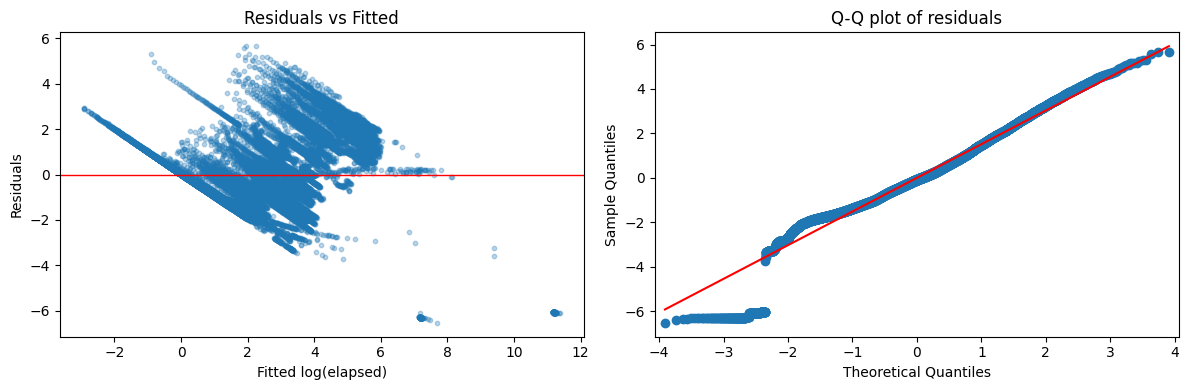

R² = 0.6361
Adj. R² = 0.6360


In [43]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(elapsed_model.fittedvalues, elapsed_model.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted log(elapsed)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(elapsed_model.resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q plot of residuals')

plt.tight_layout()
plt.show()

print(f'R² = {elapsed_model.rsquared:.4f}')
print(f'Adj. R² = {elapsed_model.rsquared_adj:.4f}')

## 8. Multivariate Multiple Regression (MANOVA)

Jointly model two correlated outputs: `log_elapsed` (time) and `log_timed_bytes` (memory).  
Predictors: `log_nvar`, `log_neval_obj`, `log_neval_grad`, `ncon`, `iter`.

Multivariate dataset: 21487 rows


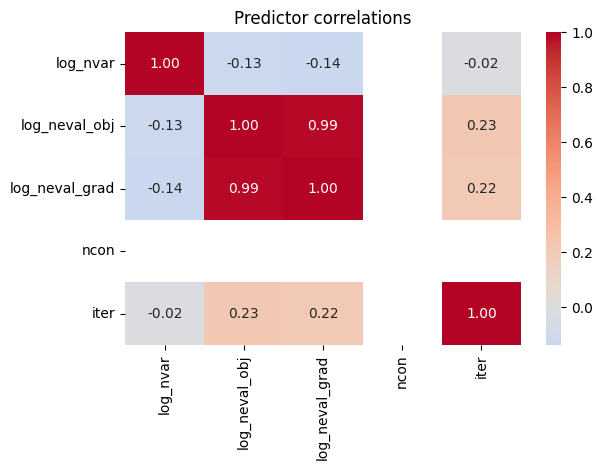


ncon value counts:
ncon
0.0000    21487
Name: count, dtype: int64

iter nulls: 0
                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.2064 2.0000 21482.0000 41286.7767 0.0000
         Pillai's trace 0.7936 2.0000 21482.0000 41286.7767 0.0000
 Hotelling-Lawley trace 3.8438 2.0000 21482.0000 41286.7767 0.0000
    Roy's greatest root 3.8438 2.0000 21482.0000 41286.7767 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
        log_nvar        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
 

In [44]:
# Prepare joint dataset for multivariate regression
multi_cols = ['log_nvar', 'log_neval_obj', 'log_neval_grad', 'ncon', 'iter',
              'log_elapsed', 'log_timed_bytes']
df_multi = df[multi_cols].dropna()
print(f'Multivariate dataset: {df_multi.shape[0]} rows')

# --- Step 1: check correlations ---
corr = df_multi[['log_nvar', 'log_neval_obj', 'log_neval_grad', 'ncon', 'iter']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Predictor correlations')
plt.tight_layout()
plt.show()

# --- Step 2: combine collinear eval columns into one ---
df_multi['log_total_evals'] = np.log1p(
    np.expm1(df_multi['log_neval_obj']) + np.expm1(df_multi['log_neval_grad'])
)

# --- Step 3: drop near-zero variance columns ---
print("\nncon value counts:"); print(df_multi['ncon'].value_counts().head())
print("\niter nulls:", df_multi['iter'].isnull().sum())

# --- Step 4: MANOVA with clean, non-collinear predictors ---
manova = MANOVA.from_formula(
    'log_elapsed + log_timed_bytes ~ log_nvar + log_total_evals + iter',
    data=df_multi
)
print(manova.mv_test())

In [45]:
# OLS per output for coefficient-level detail
X_multi = sm.add_constant(df_multi[['log_nvar', 'log_neval_obj', 'log_neval_grad', 'ncon', 'iter']])

# --- Output 1: log elapsed time ---
model_time = sm.OLS(df_multi['log_elapsed'], X_multi).fit()
print('=== OUTPUT 1: log(stats_elapsed_time) ===')
print(model_time.summary())

=== OUTPUT 1: log(stats_elapsed_time) ===
                            OLS Regression Results                            
Dep. Variable:            log_elapsed   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                 2.126e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:48:38   Log-Likelihood:                -33096.
No. Observations:               21487   AIC:                         6.620e+04
Df Residuals:                   21482   BIC:                         6.624e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
co

/home/gaoyuc10/projects/AutoJSOSolverSelection.jl/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [46]:
# --- Output 2: log timed_bytes (memory) ---
model_mem = sm.OLS(df_multi['log_timed_bytes'], X_multi).fit()
print('=== OUTPUT 2: log(timed_bytes) ===')
print(model_mem.summary())

=== OUTPUT 2: log(timed_bytes) ===
                            OLS Regression Results                            
Dep. Variable:        log_timed_bytes   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.846e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:48:38   Log-Likelihood:                -32499.
No. Observations:               21487   AIC:                         6.501e+04
Df Residuals:                   21482   BIC:                         6.505e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const    

/home/gaoyuc10/projects/AutoJSOSolverSelection.jl/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [47]:
# Side-by-side coefficient comparison
coef_df = pd.DataFrame({
    'coef_time':   model_time.params,
    'pval_time':   model_time.pvalues,
    'coef_memory': model_mem.params,
    'pval_memory': model_mem.pvalues,
})
coef_df['sig_time']   = coef_df['pval_time'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
coef_df['sig_memory'] = coef_df['pval_memory'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
print(coef_df.round(4))

                coef_time  pval_time  coef_memory  pval_memory sig_time  \
const             -6.7955     0.0000       7.4059       0.0000      ***   
log_nvar           0.9871     0.0000       0.9208       0.0000      ***   
log_neval_obj     -0.2779     0.0000       0.0033       0.9046      ***   
log_neval_grad     0.6877     0.0000       0.1648       0.0000      ***   
ncon               0.0000        NaN       0.0000          NaN            
iter               0.0000     0.0000       0.0000       0.0000      ***   

               sig_memory  
const                 ***  
log_nvar              ***  
log_neval_obj              
log_neval_grad        ***  
ncon                       
iter                  ***  


## 9. Diagnostics — Both Models

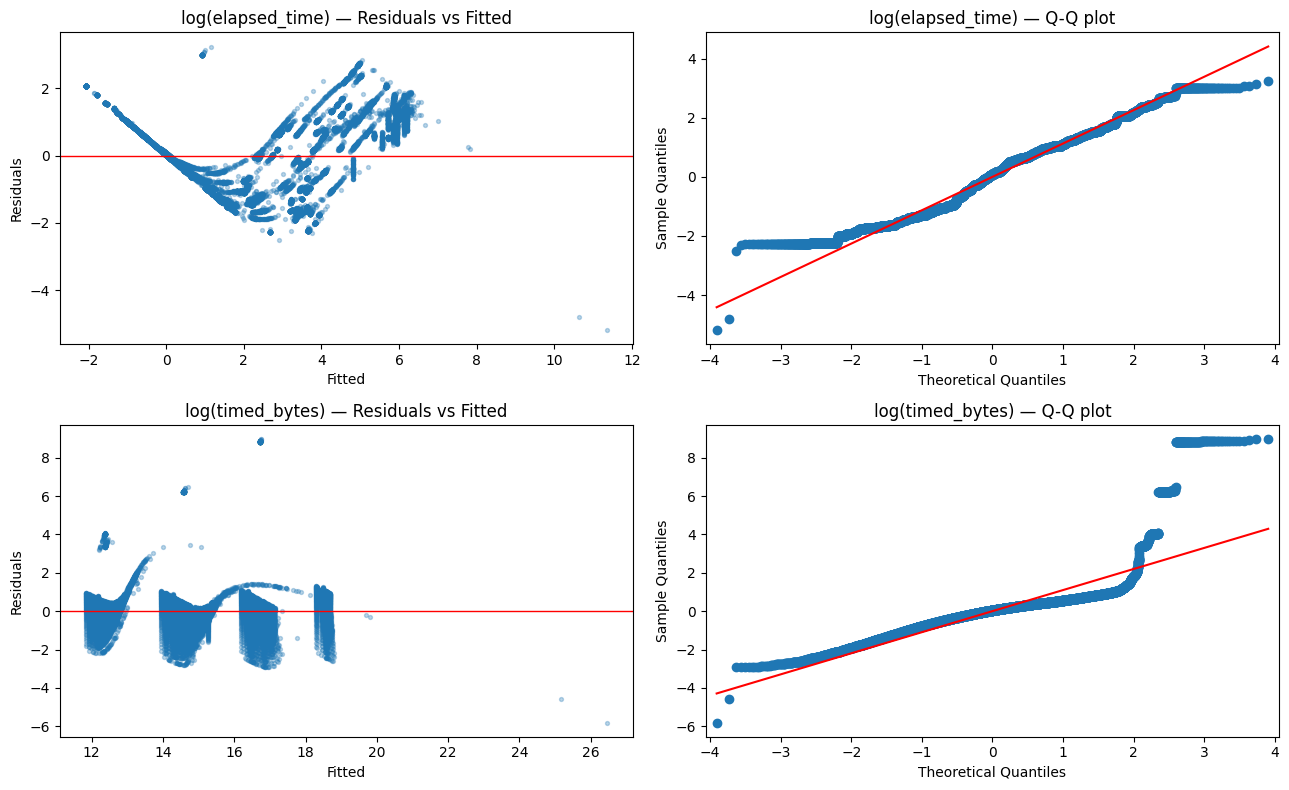

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (model, title) in enumerate([(model_time, 'log(elapsed_time)'), (model_mem, 'log(timed_bytes)')]):
    # Residuals vs Fitted
    axes[row, 0].scatter(model.fittedvalues, model.resid, alpha=0.3, s=8)
    axes[row, 0].axhline(0, color='red', lw=1)
    axes[row, 0].set_xlabel('Fitted')
    axes[row, 0].set_ylabel('Residuals')
    axes[row, 0].set_title(f'{title} — Residuals vs Fitted')
    
    # Q-Q plot
    sm.qqplot(model.resid, line='s', ax=axes[row, 1])
    axes[row, 1].set_title(f'{title} — Q-Q plot')

plt.tight_layout()
plt.show()

## 10. Report — Next Steps

- [ ] **Felix:** Send email summary of results to Tangi and Nishan  
- [ ] **Tangi:** Investigate `time_limit` and `error_*` rows skipped in the original script  
- [ ] **All:** Agree on final bin boundaries for `cat_time` and `cat_nvar`  
- [ ] **All:** Add more features from the 98 columns to `feature_cols` and re-run  
- [ ] **All:** Start column description section in the report (Section 3 above is a starting point)